In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

# %matplotlib qt
%matplotlib inline

In [3]:
cd ../

c:\Users\eduar\Documents\usp\MATEMATICA\trabalho_final\pca_anomaly_detection


In [5]:
df_new = pd.read_feather('data/processed/TEP_Training.feather').head(5)
df_new

,faultNumber,fault_description,simulationRun,sample,a_feed_stream1_kscmh,d_feed_stream2_kg_h,e_feed_stream3_kg_h,a_and_c_feed_stream4_kscmh,recycle_flow_stream8_kscmh,reactor_feed_rate_stream6_kscmh,...,e_feed_flow_stream3_kg_h,a_feed_flow_stream1_kscmh,a_and_c_feed_flow_stream4_kscmh,compressor_recycle_valve_pct,purge_valve_stream9_pct,separator_pot_liquid_flow_stream10_m3_h,stripper_liquid_product_flow_stream11_m3_h,stripper_steam_valve_pct,reactor_cooling_water_flow_m3_h,condenser_cooling_water_flow_m3_h
0,0,normal_operation,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0,normal_operation,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0,normal_operation,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0,normal_operation,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0,normal_operation,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [3]:
df_new = pd.read_feather('data/preprocessed/TEP_FaultFree_Training.feather')
df_new2 = pd.read_feather('data/preprocessed/TEP_Faulty_Training.feather')
df = pd.concat([df_new, df_new2], axis=0)

In [ ]:
# TEP_dataset1 corresponde as amostras originalmente de TREINO (sem e com anomalia)

path = 'C:/Users/c25t/OneDrive - TRANSPETRO/ZORATTI/_Documentos Pessoais/USP/MECAI/_Disciplinas/6_Topicos MECAI/Dataset/' # caminho do dataset salvo
df = pd.read_feather(path + 'TEP_dataset1.feather')
df

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5249995,20.0,500.0,496,0.23419,3655.3,4461.7,9.3448,27.008,42.481,2703.0,...,53.670,23.350,61.061,20.719,40.999,38.653,47.386,47.528,40.212,17.659
5249996,20.0,500.0,497,0.26704,3647.4,4540.2,9.3546,27.034,42.671,2704.7,...,54.650,26.362,60.020,20.263,41.579,33.624,47.536,47.647,41.199,18.741
5249997,20.0,500.0,498,0.26543,3630.3,4571.6,9.4089,27.129,42.470,2705.1,...,54.274,26.521,59.824,20.189,41.505,40.967,52.437,47.802,41.302,23.199
5249998,20.0,500.0,499,0.27671,3655.7,4498.9,9.3781,27.353,42.281,2705.8,...,53.506,26.781,62.818,20.453,40.208,40.957,47.628,48.086,40.510,15.932


In [4]:
df_train = df[(df['faultNumber']==0)].iloc[:,3:] # conjunto de dados para a condição sem falha para todas as 500 simulações distintas

# df_train = df[(df['faultNumber']==0) & (df['simulationRun']>=1) & (df['simulationRun']<5)].iloc[:,3:] # conjunto de dados sem falha (faultNumber = 0) para as simulações entre 1 e 4
# df_test = df[(df['faultNumber']==0) & (df['simulationRun']>5) & (df['simulationRun']<10)].iloc[:,3:] # conjunto de dados sem falha (faultNumber = 0) para as simulações entre 6 e 9

In [5]:
# guardando médias e desvios-padrão do treino
mu_train = df_train.mean(axis=0)
std_train = df_train.std(axis=0)


# normalizando dados de treino
df_train_norm = np.array(((df_train - mu_train)/std_train))

In [6]:
# Treinamento (FIT) do modelo: cálculo das componentes principais
pca = PCA()
pca.fit(df_train_norm)


PCA()

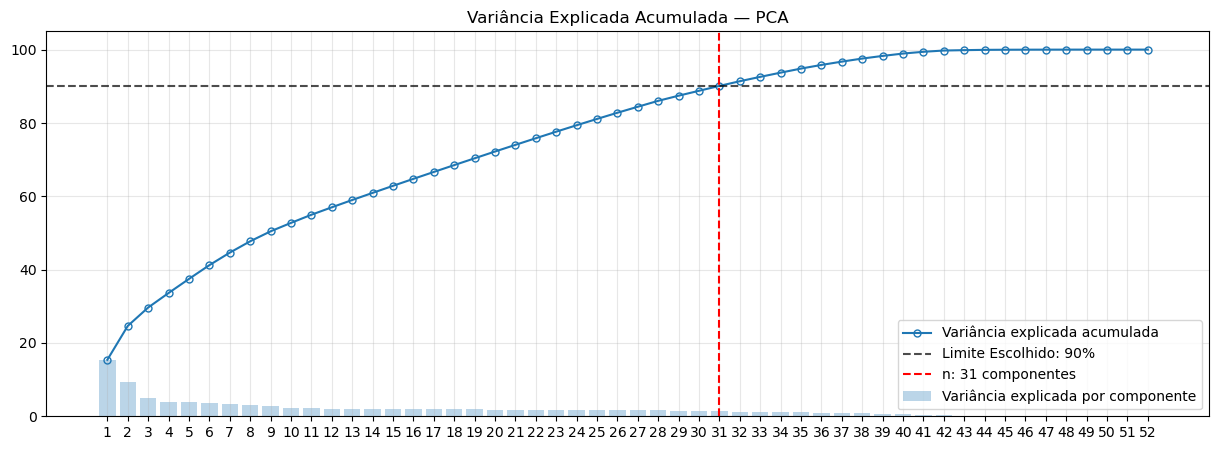

In [7]:
# Variância explicada acumulada
variancia_explicada_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100
array_n_componentes = np.arange(1, pca.n_components_ + 1)

limite_variancia_explicada = 90 # porcentagem da variância explicada necessária escolhida
n_componentes_limite = np.argmax(variancia_explicada_acumulada >= limite_variancia_explicada)+1 # número de componentes principais necessárias para o limiar escolhido


fig = plt.figure(figsize=(15, 5))

# Barras — variância por componente
plt.bar(array_n_componentes, pca.explained_variance_ratio_ * 100, alpha=0.3, label='Variância explicada por componente')

# Linha — variância acumulada
plt.plot(array_n_componentes, variancia_explicada_acumulada, marker='o', markersize=5, markerfacecolor='none', label='Variância explicada acumulada')

plt.axhline(y=limite_variancia_explicada, linestyle='--', color='black', alpha=0.7, label=f'Limite Escolhido: {limite_variancia_explicada}%')
plt.axvline(x=n_componentes_limite, linestyle='--', color='red', linewidth=1.5, label=f'n: {n_componentes_limite} componentes')

plt.title('Variância Explicada Acumulada — PCA')
plt.xticks(array_n_componentes)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
# Transformação (projeção no espaço PCA)
T_train = pca.transform(df_train_norm)

# Seleção das primeiras componentes para a porcentagem da variância explicada selecionada. As componenetes adicionais são zeradas
T_train_truncado = T_train.copy()
T_train_truncado[:, n_componentes_limite:] = 0

# Reconstrução dos dados no espaço original
df_train_norm_reconstruido = pca.inverse_transform(T_train_truncado)

# Erro de reconstrução por amostra
erro = df_train_norm - df_train_norm_reconstruido # erro (vetor) para cada amostra: (n_amostras, n_features)
SPE_train = np.sum(erro ** 2, axis=1) # Square Prediction Error (escalar) para cada amostra: (n_amostras,)

# Cálculo do limite de aceitação para o SPE de uma amostra
limite_percentil = 99
threshold_SPE = np.percentile(SPE_train, limite_percentil)

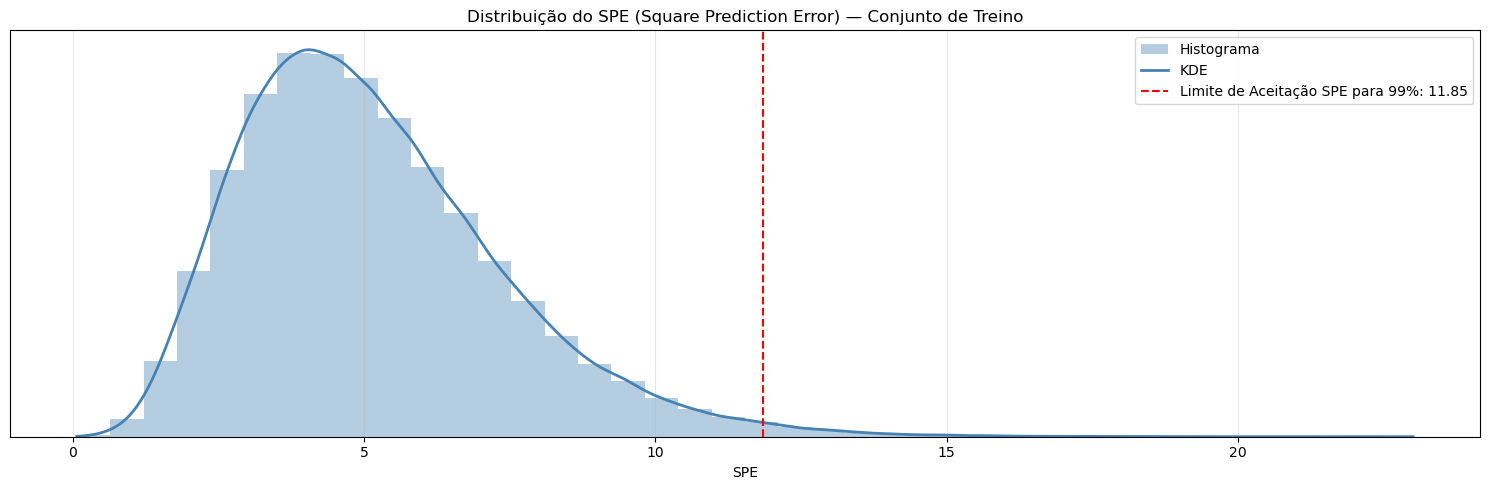

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))

# Histograma
ax.hist(SPE_train, bins=40, density=True, alpha=0.4, color='steelblue', label='Histograma')

# KDE: kernel density estimation
kde = gaussian_kde(SPE_train)
x = np.linspace(SPE_train.min(), SPE_train.max(), 300)
ax.plot(x, kde(x), color='steelblue', linewidth=2, label='KDE')

ax.axvline(x=threshold_SPE, linestyle='--', color='red',linewidth=1.5, label=f'Limite de Aceitação SPE para {limite_percentil}%: {threshold_SPE:.2f}')

ax.set_xlabel('SPE')
ax.set_yticks([])
ax.set_title('Distribuição do SPE (Square Prediction Error) — Conjunto de Treino')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

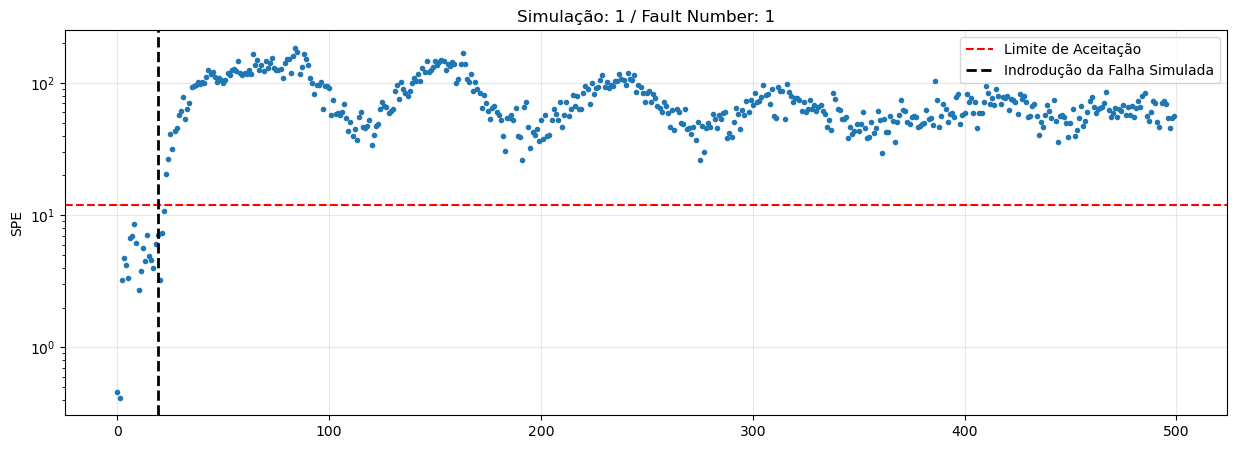

In [10]:
# Dados de Teste
fault_number = 1
simulation_run = 1
df_test = df[(df['faultNumber']==fault_number) & (df['simulationRun'] == simulation_run)].iloc[:,3:]

# normalizando dados de teste com a média e desvio padrão do conjunto de treino
df_test_norm = np.array(((df_test - mu_train)/std_train))

# Transformação (projeção no espaço PCA)
T_test = pca.transform(df_test_norm)

# Seleção das primeiras componentes para a porcentagem da variância explicada selecionada. As componenetes adicionais são zeradas
T_test_truncado = T_test.copy()
T_test_truncado[:, n_componentes_limite:] = 0

# Reconstrução dos dados no espaço original
df_test_norm_reconstruido = pca.inverse_transform(T_test_truncado)

# Erro de reconstrução por amostra
erro = df_test_norm - df_test_norm_reconstruido # erro (vetor) para cada amostra: (n_amostras, n_features)
SPE_test = np.sum(erro ** 2, axis=1) # Square Prediction Error (escalar) para cada amostra: (n_amostras,)

##############################################################

fig, ax = plt.subplots(figsize=(15, 5))

ax.semilogy(SPE_test,'.')
ax.axhline(threshold_SPE,ls='--',c='r', label='Limite de Aceitação')
plt.axvline(x = 19, color = 'k', linestyle = '--', label='Indrodução da Falha Simulada', linewidth=2) 

ax.set_title(f'Simulação: {simulation_run} / Fault Number: {fault_number}')
ax.set_ylabel('SPE')
ax.grid(True, alpha=0.3)
ax.legend()

# __________________________________________

C:\Users\c25t\AppData\Local\Temp\ipykernel_12932\3781500157.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax[0,0].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,3].values, alpha=1, color = 'g', label = 'Telemetrias condição sem falha')
C:\Users\c25t\AppData\Local\Temp\ipykernel_12932\3781500157.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax[0,0].plot(x2, df[df['faultNumber']==tipo_falha][df['simulationRun'] == 1].iloc[:,3].values, alpha=0.5, color = 'b', label = 'Telemetrias condição com falha do tipo 1')
C:\Users\c25t\AppData\Local\Temp\ipykernel_12932\3781500157.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax[0,1].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,4].values, alpha=1, color = 'g')
C:\Users\c25t\AppData\Local\Temp\ipykernel_12932\3781500157.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame 

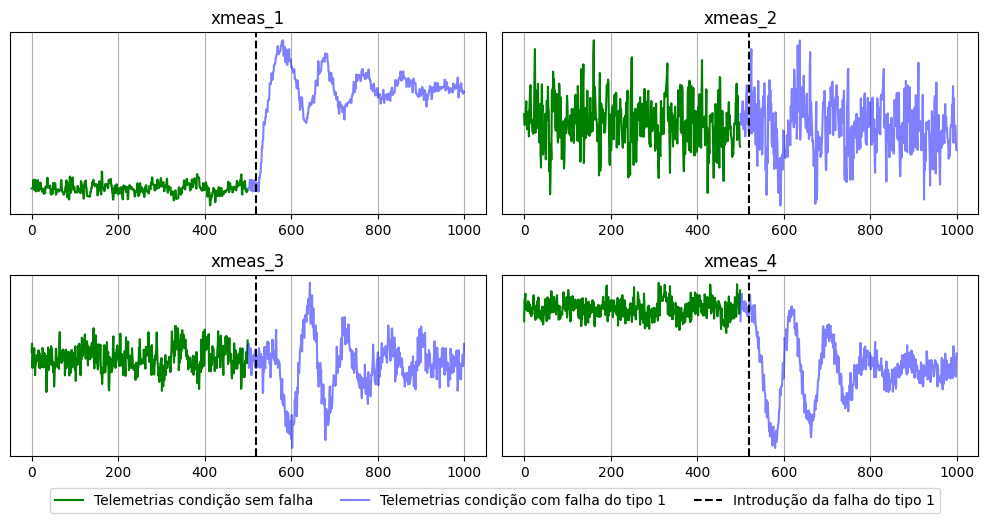

In [78]:
# %matplotlib qt
%matplotlib inline

tipo_falha = 1

x1 = np.arange(500)
# x2 = np.arange(500)
x2 = np.arange(500, 1000)

x_falha = x2[19]

fig, ax = plt.subplots(2,2, figsize=(10,5))

ax[0,0].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,3].values, alpha=1, color = 'g', label = 'Telemetrias condição sem falha')
ax[0,0].plot(x2, df[df['faultNumber']==tipo_falha][df['simulationRun'] == 1].iloc[:,3].values, alpha=0.5, color = 'b', label = 'Telemetrias condição com falha do tipo 1')
ax[0,0].axvline(x_falha, color='k', linestyle='--', label = 'Introdução da falha do tipo 1')

ax[0,1].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,4].values, alpha=1, color = 'g')
ax[0,1].plot(x2, df[df['faultNumber']==tipo_falha][df['simulationRun'] == 1].iloc[:,4].values, alpha=0.5, color = 'b')
ax[0,1].axvline(x_falha, color='k', linestyle='--')

ax[1,0].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,5].values, alpha=1, color = 'g')
ax[1,0].plot(x2, df[df['faultNumber']==tipo_falha][df['simulationRun'] == 1].iloc[:,5].values, alpha=0.5, color = 'b')
ax[1,0].axvline(x_falha, color='k', linestyle='--')

ax[1,1].plot(x1, df[df['faultNumber']==0][df['simulationRun'] == 1].iloc[:,6].values, alpha=1, color = 'g')
ax[1,1].plot(x2, df[df['faultNumber']==tipo_falha][df['simulationRun'] == 1].iloc[:,6].values, alpha=0.5, color = 'b')
ax[1,1].axvline(x_falha, color='k', linestyle='--')

ax[0,0].grid(True)
ax[0,1].grid(True)
ax[1,0].grid(True)
ax[1,1].grid(True)

ax[0,0].set_yticks([])
ax[0,1].set_yticks([])
ax[1,0].set_yticks([])
ax[1,1].set_yticks([])

ax[0,0].set_title("xmeas_1")
ax[0,1].set_title("xmeas_2")
ax[1,0].set_title("xmeas_3")
ax[1,1].set_title("xmeas_4")

# set legend position
fig.legend( bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=3)

plt.tight_layout()

# plt.savefig("Imagens/TEP_telemetrias_2.jpg", bbox_inches='tight')